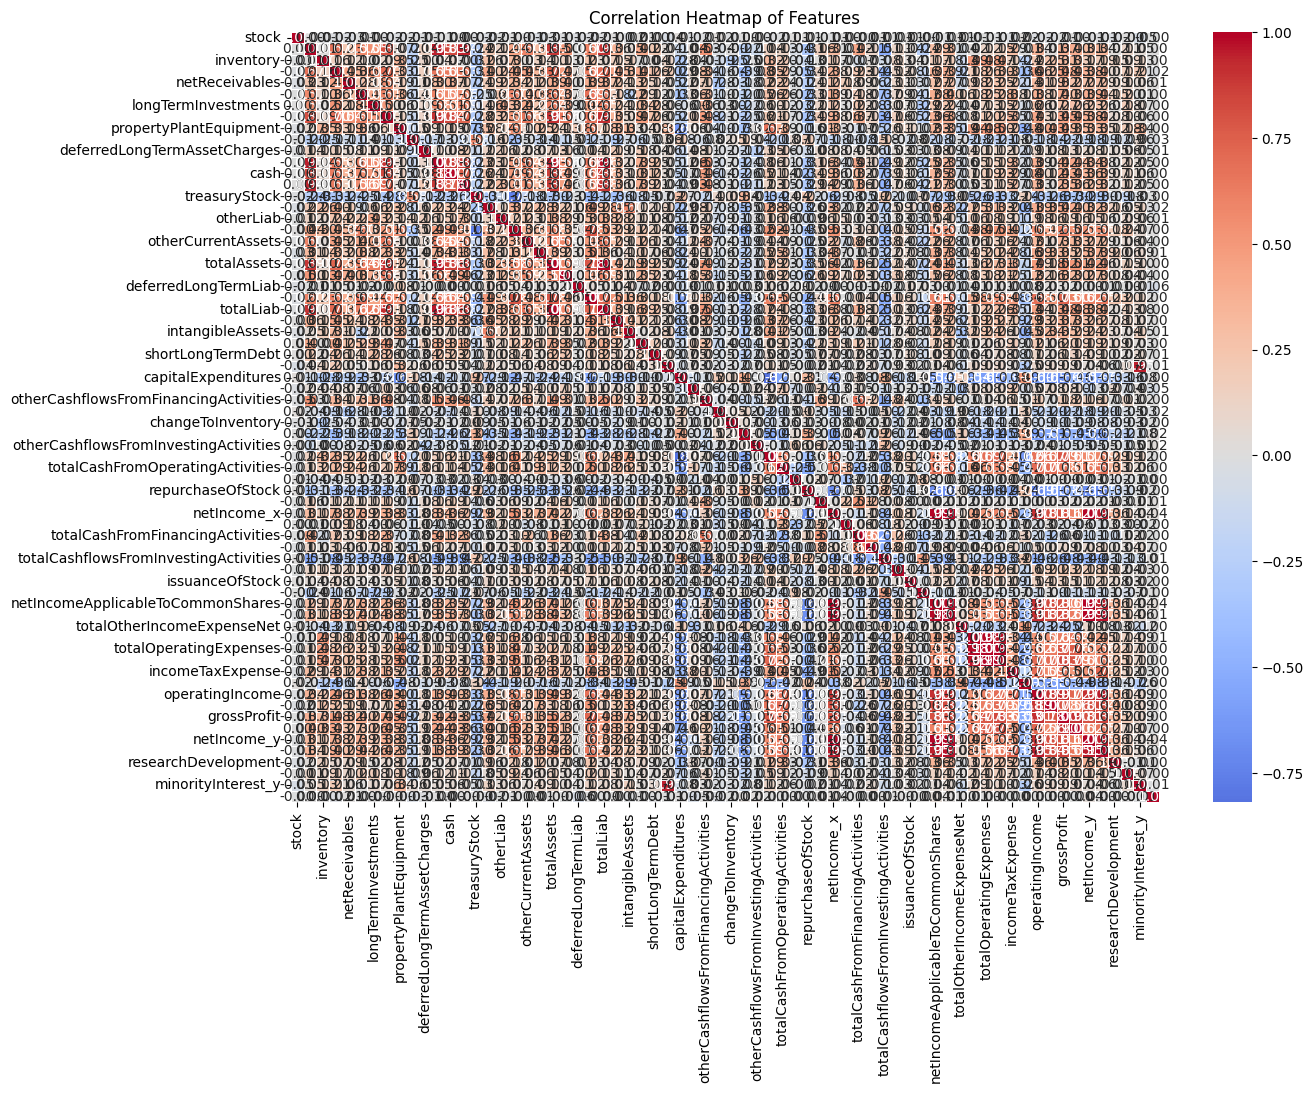

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------- Load Data ----------------------
annual_data = pd.read_csv("new_data/new_balance_cashflow_incom_annualmerged.csv")
quarterly_data = pd.read_csv("new_data/new_balance_cashflow_incom_quarterlymerged.csv")

# Combine both datasets
df = pd.concat([annual_data, quarterly_data], ignore_index=True)

# ---------------------- Preprocessing ----------------------
# Drop non-numeric columns (e.g., 'stock' after label encoding, 'endDate' etc.)
df['endDate'] = pd.to_datetime(df['endDate'], errors='coerce')
df.dropna(subset=['endDate'], inplace=True)
df['stock'] = df['stock'].astype('category').cat.codes  # If not already done

# Drop 'endDate' after encoding 'stock' if not needed anymore
df.drop(columns=['endDate'], inplace=True)

# ---------------------- Correlation Matrix ----------------------
correlation_matrix = df.corr()

# ---------------------- Plot Heatmap ----------------------
plt.figure(figsize=(14, 10))  # Set the size of the plot
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()


In [3]:
df['profit_loss'] = (df['netIncome_x'] > 0).astype(int)

# Extract features and target
features = [col for col in df.columns if col != 'profit_loss']
X = df[features]
y = df['profit_loss']

# ---------------------- Cross-Validation ----------------------

from sklearn.model_selection import cross_val_score
import numpy as np
import xgboost as xgb

# Define the model
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    max_depth=6,
    n_estimators=100,
    learning_rate=0.1
)

# Perform cross-validation (using 5 folds as an example)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Print out the cross-validation scores and the mean
print(f"Cross-Validation Scores (Accuracy) for each fold: {cv_scores}")
print(f"Mean Accuracy across 5 folds: {np.mean(cv_scores):.2f}")

C:\Users\Atharv\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:37:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Atharv\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:37:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Atharv\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:37:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } 

Cross-Validation Scores (Accuracy) for each fold: [1.         0.99985797 0.99928987 0.99900582 0.99886364]
Mean Accuracy across 5 folds: 1.00
